In [1]:
import pandas as pd, yfinance as yf
daily = yf.download("META", period="5y", interval="1d")
market_daily = yf.download("SPY", period="5y", interval="1d")
weekly = yf.download("META", period="5y", interval="1wk")
from base_identification import find_all_bases, find_ranges


/var/folders/jg/dt8f9z8s7f5gtvdq0cqqmc2h0000gn/T/ipykernel_62863/3212245714.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  daily = yf.download("META", period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/var/folders/jg/dt8f9z8s7f5gtvdq0cqqmc2h0000gn/T/ipykernel_62863/3212245714.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_daily = yf.download("SPY", period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/var/folders/jg/dt8f9z8s7f5gtvdq0cqqmc2h0000gn/T/ipykernel_62863/3212245714.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  weekly = yf.download("META", period="5y", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [2]:
import pandas as pd, yfinance as yf
daily = yf.download("META", period="max", interval="1d", auto_adjust=False)


[*********************100%***********************]  1 of 1 completed


In [12]:
ticker = yf.Ticker("AAPL")

# Fetch recent and future earnings dates
earnings_dates = ticker.get_earnings_dates(limit = 1000)
print(earnings_dates)

                           EPS Estimate  Reported EPS  Surprise(%) Event Type
Earnings Date                                                                
2025-05-01 16:30:00-04:00          1.63          1.65         1.41   Earnings
2025-02-27 12:00:00-05:00           NaN           NaN          NaN    Meeting
2025-01-30 16:31:00-05:00          2.35          2.40         2.15   Earnings
2024-10-31 16:31:00-04:00          1.60          1.64         2.35   Earnings
2024-08-01 16:30:00-04:00          1.35          1.40         3.99   Earnings
...                                 ...           ...          ...        ...
2000-10-18 00:00:00-04:00          0.01          0.01        -3.94   Earnings
2000-07-18 00:00:00-04:00          0.01          0.01         3.08   Earnings
2000-04-19 00:00:00-04:00          0.01          0.01         9.62   Earnings
2000-01-19 00:00:00-05:00          0.01          0.01        11.21   Earnings
1999-10-13 00:00:00-04:00           NaN           NaN        12.

In [3]:
daily


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META,META
Date,,,,,,
2012-05-18,37.932327,38.230000,45.000000,38.000000,42.049999,573576400
2012-05-21,33.765034,34.029999,36.660000,33.000000,36.529999,168192700
2012-05-22,30.758619,31.000000,33.590000,30.940001,32.610001,101786600
2012-05-23,31.750837,32.000000,32.500000,31.360001,31.370001,73600000
2012-05-24,32.772820,33.029999,33.209999,31.770000,32.950001,50237200
...,...,...,...,...,...,...
2026-06-08,585.390015,585.390015,592.000000,579.219971,592.000000,19512400
2026-06-09,584.590027,584.590027,597.630005,581.010010,591.000000,16977400


In [1]:
import pandas as pd, yfinance as yf
from stage_analysis import compute_stage_analysis
weekly = yf.download("NVDA", period="max", interval="1wk", auto_adjust=False)
market_weekly = yf.download("SPY", period="max", interval="1wk", auto_adjust=False)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
x = compute_stage_analysis(weekly, market_weekly)

[S2 TRENDLINE] 2000-01-31 | new pivot low: 0.0729
  all pivot lows : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729)]
  ascending lows : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729)]
  anchor lows    : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729)]
  trendline      : m=0.002001  b=-0.035143
[S2 TRENDLINE] 2000-04-03 | new pivot low: 0.1187
  all pivot lows : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729), (datetime.date(2000, 4, 3), 0.1187)]
  ascending lows : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729), (datetime.date(2000, 4, 3), 0.1187)]
  anchor lows    : [(datetime.date(2000, 1, 31), 0.0729), (datetime.date(2000, 4, 3), 0.1187)]
  trendline      : m=0.005093  b=-0.202081
[S2 TRENDLINE] 2000-07-24 | new pivot low: 0.2083
  all pivot lows : [(datetime.date(1999, 9, 20), 0.0349), (datetime.date(2000, 1, 31), 0.0729), (datetime.date(2000

In [3]:
import pprint
pprint.pprint(x.segments)

[StageSegment(state=0,
              start_date=Timestamp('1999-01-18 00:00:00'),
              end_date=Timestamp('1999-06-07 00:00:00'),
              entry_trigger='init',
              stage1_floor=None,
              stage1_ceiling=None,
              stage1_ceiling_locked=False,
              stage2_line_m=None,
              stage2_line_b=None,
              stage2_anchor_pivots=[],
              stage3_floor=None,
              stage3_ceiling=None),
 StageSegment(state=1,
              start_date=Timestamp('1999-06-14 00:00:00'),
              end_date=Timestamp('1999-11-08 00:00:00'),
              entry_trigger='higher_pivot_low',
              stage1_floor=0.03333299979567528,
              stage1_ceiling=0.05911500006914139,
              stage1_ceiling_locked=False,
              stage2_line_m=None,
              stage2_line_b=None,
              stage2_anchor_pivots=[],
              stage3_floor=None,
              stage3_ceiling=None),
 StageSegment(state=2,
           

In [1]:
import pandas as pd, yfinance as yf
from base_identification import find_all_bases, find_ranges
daily = yf.download("IBKR", period="max", interval="1d", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [2]:
ranges = find_ranges(daily, box_pct=4.0, expansion_pct=4.0, close_threshold_pct=40.0, max_expansion_days=1, price_mode = 'open_close')
strong_breakouts = [r for r in ranges if r.expansion and r.expansion.direction == "up" and r.expansion.strong_close ]#and r.slope_21ema!=None and r.slope_50dma!=None and (r.slope_50dma>=0 or r.slope_21ema>=0)

In [3]:
trades = [[r.trade.return_pct, r.trade.buy.date, r.trade.buy.price, r.trade.sell.sell_date if r.trade.sell else None, r.trade.sell.sell_price if r.trade.sell else None] for r in strong_breakouts]

In [4]:
trades

[[-4.06,
  Timestamp('2007-08-23 00:00:00'),
  6.65,
  Timestamp('2007-09-07 00:00:00'),
  6.38],
 [1.39,
  Timestamp('2007-10-02 00:00:00'),
  6.82,
  Timestamp('2007-11-09 00:00:00'),
  6.92],
 [-4.04,
  Timestamp('2007-12-21 00:00:00'),
  8.17,
  Timestamp('2007-12-31 00:00:00'),
  7.84],
 [-0.36,
  Timestamp('2008-04-28 00:00:00'),
  7.7,
  Timestamp('2008-05-22 00:00:00'),
  7.68],
 [-3.99,
  Timestamp('2008-06-06 00:00:00'),
  8.59,
  Timestamp('2008-06-06 00:00:00'),
  8.25],
 [-3.97,
  Timestamp('2008-06-16 00:00:00'),
  8.57,
  Timestamp('2008-06-19 00:00:00'),
  8.23],
 [-3.94,
  Timestamp('2008-08-11 00:00:00'),
  7.11,
  Timestamp('2008-08-12 00:00:00'),
  6.83],
 [-3.95,
  Timestamp('2008-12-31 00:00:00'),
  4.3,
  Timestamp('2009-01-22 00:00:00'),
  4.13],
 [-4.09,
  Timestamp('2009-01-29 00:00:00'),
  4.16,
  Timestamp('2009-01-29 00:00:00'),
  3.99],
 [-3.94,
  Timestamp('2009-04-16 00:00:00'),
  4.25,
  Timestamp('2009-04-20 00:00:00'),
  4.08],
 [-1.69,
  Timestamp('2

In [10]:
#print(sum([x[2] for x in trades]))
#print(sum([x[2] for x in trades]))
[x[4] for x in trades]

[6.38,
 6.92,
 7.84,
 7.68,
 8.25,
 8.23,
 6.83,
 4.13,
 3.99,
 4.08,
 3.78,
 4.5,
 4.79,
 4.08,
 4.53,
 4.37,
 3.96,
 3.69,
 4.09,
 5.81,
 5.74,
 8.4,
 10.33,
 10.23,
 10.43,
 10.55,
 9.43,
 9.33,
 16.86,
 16.03,
 16.86,
 18.38,
 13.37,
 13.16,
 12.35,
 10.59,
 15.87,
 19.12,
 15.6,
 18.35,
 27.3,
 44.5,
 50.71,
 66.56,
 70.6,
 74.04,
 None]

In [8]:
[x.end_date for x in strong_breakouts]

[Timestamp('2007-08-21 00:00:00'),
 Timestamp('2007-09-28 00:00:00'),
 Timestamp('2007-12-19 00:00:00'),
 Timestamp('2008-04-24 00:00:00'),
 Timestamp('2008-06-04 00:00:00'),
 Timestamp('2008-06-12 00:00:00'),
 Timestamp('2008-08-07 00:00:00'),
 Timestamp('2008-12-29 00:00:00'),
 Timestamp('2009-01-27 00:00:00'),
 Timestamp('2009-04-14 00:00:00'),
 Timestamp('2009-06-24 00:00:00'),
 Timestamp('2009-07-23 00:00:00'),
 Timestamp('2009-08-06 00:00:00'),
 Timestamp('2010-04-22 00:00:00'),
 Timestamp('2010-10-21 00:00:00'),
 Timestamp('2010-12-02 00:00:00'),
 Timestamp('2011-03-01 00:00:00'),
 Timestamp('2012-11-20 00:00:00'),
 Timestamp('2013-05-01 00:00:00'),
 Timestamp('2013-11-11 00:00:00'),
 Timestamp('2014-04-15 00:00:00'),
 Timestamp('2015-03-10 00:00:00'),
 Timestamp('2015-04-21 00:00:00'),
 Timestamp('2015-07-31 00:00:00'),
 Timestamp('2015-10-27 00:00:00'),
 Timestamp('2015-11-05 00:00:00'),
 Timestamp('2016-05-17 00:00:00'),
 Timestamp('2017-02-28 00:00:00'),
 Timestamp('2017-10-

In [11]:
import pprint

pprint.pprint(strong_breakouts)

[Range(start_date=Timestamp('2007-08-17 00:00:00'),
       end_date=Timestamp('2007-08-21 00:00:00'),
       high=6.33,
       low=6.17,
       height_pct=2.59,
       length_days=3,
       price_mode='open_close',
       expansion=RangeExpansion(date=Timestamp('2007-08-22 00:00:00'),
                                direction='up',
                                close=6.65,
                                day_chg_pct=4.97,
                                move_pct=4.97,
                                day_high=6.68,
                                day_low=6.38,
                                day_range_pct=4.86,
                                closing_range_pct=87.9,
                                strong_close=True),
       trade=RangeExpansionTrade(buy=Buy(date=Timestamp('2007-08-23 00:00:00'),
                                         price=6.65,
                                         stop_loss=StopLoss(stop_type='expansion_open',
                                                   

In [2]:
bases = find_all_bases(daily, market_daily=market_daily, weekly=weekly, pivot_percentile=100)
for b in bases:
    
    print(b)
    

Base(start_date=Timestamp('2024-07-15 00:00:00'), end_date=Timestamp('2024-12-02 00:00:00'), base_high=239.48, base_high_date=Timestamp('2024-12-02 00:00:00'), base_low=194.5, base_low_date=Timestamp('2024-08-05 00:00:00'), depth_pct=-18.78, effective_pivot=239.48, pivot_tolerance_pct=0.0, length_days=99, length_weeks=19.8, prior_uptrend_pct=47.28, prior_trough=162.6, prior_trough_date=Timestamp('2024-04-19 00:00:00'), prior_uptrend_sufficient=True, market_drawdown_pct=-15.82, depth_vs_market_ratio=1.19, depth_vs_market_passes=True, active=False, breakout_confirmed=True, stage_number=1, early_stage=True, pattern='VCP', handle_detected=False, vcp_swings=[17.4, 9.9, 8.8], vcp_contracting=True, accum_weeks=2, distrib_weeks=1, accum_distrib_ratio=2.0, accum_passes=True, three_weeks_tight=[ThreeWeeksTight(start_date=Timestamp('2024-08-12 00:00:00'), end_date=Timestamp('2024-08-26 00:00:00'), num_weeks=3, closes=[224.32, 225.36, 227.51], spread_pct=1.4), ThreeWeeksTight(start_date=Timestamp(

In [3]:
import pprint
pprint.pprint(bases[0])

Base(start_date=Timestamp('2024-07-15 00:00:00'),
     end_date=Timestamp('2024-12-02 00:00:00'),
     base_high=239.48,
     base_high_date=Timestamp('2024-12-02 00:00:00'),
     base_low=194.5,
     base_low_date=Timestamp('2024-08-05 00:00:00'),
     depth_pct=-18.78,
     effective_pivot=239.48,
     pivot_tolerance_pct=0.0,
     length_days=99,
     length_weeks=19.8,
     prior_uptrend_pct=47.28,
     prior_trough=162.6,
     prior_trough_date=Timestamp('2024-04-19 00:00:00'),
     prior_uptrend_sufficient=True,
     market_drawdown_pct=-15.82,
     depth_vs_market_ratio=1.19,
     depth_vs_market_passes=True,
     active=False,
     breakout_confirmed=True,
     stage_number=1,
     early_stage=True,
     pattern='VCP',
     handle_detected=False,
     vcp_swings=[17.4, 9.9, 8.8],
     vcp_contracting=True,
     accum_weeks=2,
     distrib_weeks=1,
     accum_distrib_ratio=2.0,
     accum_passes=True,
     three_weeks_tight=[ThreeWeeksTight(start_date=Timestamp('2024-08-12 00:00

In [ ]:
(bases)

[Base(start_date=Timestamp('2024-07-15 00:00:00'), end_date=Timestamp('2024-12-03 00:00:00'), base_high=241.44, base_high_date=Timestamp('2024-12-03 00:00:00'), base_low=194.5, base_low_date=Timestamp('2024-08-05 00:00:00'), depth_pct=-19.44, effective_pivot=241.44, pivot_tolerance_pct=0.0, length_days=100, length_weeks=20.0, prior_uptrend_pct=48.49, prior_trough=162.6, prior_trough_date=Timestamp('2024-04-19 00:00:00'), prior_uptrend_sufficient=True, market_drawdown_pct=None, depth_vs_market_ratio=None, depth_vs_market_passes=False, active=False, breakout_confirmed=True, stage_number=1, early_stage=True, pattern='VCP', handle_detected=False, vcp_swings=[17.4, 9.9, 9.6], vcp_contracting=True, accum_weeks=2, distrib_weeks=1, accum_distrib_ratio=2.0, accum_passes=True, three_weeks_tight=[ThreeWeeksTight(start_date=Timestamp('2024-08-16 00:00:00'), end_date=Timestamp('2024-08-30 00:00:00'), closes=[224.57, 225.36, 227.51], spread_pct=1.29), ThreeWeeksTight(start_date=Timestamp('2024-09-20

In [26]:
daily.loc['2024-04-11']

Price   Ticker
Close   AAPL      1.734614e+02
High    AAPL      1.738776e+02
Low     AAPL      1.666434e+02
Open    AAPL      1.668218e+02
Volume  AAPL      9.107030e+07
Name: 2024-04-11 00:00:00, dtype: float64

In [31]:
base_slice = daily.loc['2024-07-15':'2024-12-03']

In [13]:
import math
from dataclasses import dataclass, field, asdict
from typing import Optional
def _to_scalar(val):
    """Safely convert numpy / pandas scalar to Python float."""
    if hasattr(val, "item"):
        return float(val.item())
    return float(val)


def _pct_change(a: float, b: float) -> Optional[float]:
    """Return (a / b - 1) * 100, or None on division issues."""
    try:
        if b is None or b == 0 or math.isnan(b):
            return None
        r = (a / b - 1) * 100
        return None if math.isnan(r) or math.isinf(r) else round(r, 2)
    except Exception:
        return None

In [36]:
base = bases[0]

In [37]:
depth = base.depth_pct
weeks = base.length_weeks

abs_depth = abs(depth)

start_loc = daily.index.get_loc(base.start_date)
end_loc = daily.index.get_loc(base.end_date)
if isinstance(start_loc, slice):
    start_loc = start_loc.start
if isinstance(end_loc, slice):
    end_loc = end_loc.start
base_slice = daily.iloc[start_loc: end_loc + 1]
n = len(base_slice)

# ── Double Bottom ──
# Split into halves, find lows in each half
mid = n // 2
first_half_low = _to_scalar(base_slice["Low"].iloc[:mid].min())
second_half_low = _to_scalar(base_slice["Low"].iloc[mid:].min())
# Between the two lows there should be a rally (middle high)
middle_high = _to_scalar(base_slice["High"].iloc[mid - n // 4: mid + n // 4].max())

middle_rally_pct = _pct_change(middle_high, min(first_half_low, second_half_low))
lows_close = abs(_pct_change(second_half_low, first_half_low) or 999) < 5

if (lows_close
        and middle_rally_pct is not None
        and middle_rally_pct >= 5
        and 15 <= abs_depth <= 50
        and weeks >= 5):
    base.pattern = "Double Bottom"

# ── VCP ──
# Split into thirds and measure swing ranges
if n >= 15:
    third = n // 3
    segments = [
        base_slice.iloc[:third],
        base_slice.iloc[third: 2 * third],
        base_slice.iloc[2 * third:],
    ]
    swings = []
    for seg in segments:
        seg_high = _to_scalar(seg["High"].max())
        seg_low = _to_scalar(seg["Low"].min())
        swing = abs(_pct_change(seg_low, seg_high) or 0)
        swings.append(round(swing, 1))

    base.vcp_swings = swings
    base.vcp_contracting = (
        len(swings) == 3
        and swings[0] > 0
        and swings[2] < swings[1] < swings[0]
    )

    if base.vcp_contracting and 10 <= abs_depth <= 50 and weeks >= 5:
        base.pattern = "VCP"

In [43]:
for seg in segments:
    seg_high = _to_scalar(seg["High"].max())
    seg_low = _to_scalar(seg["Low"].min())
    print(seg_high, seg_low)
    swing = abs(_pct_change(seg_low, seg_high) or 0)
    swings.append(round(swing, 1))

235.409341553401 194.49576385779395
235.9401275315396 212.52394807405793
241.441083276618 218.27619425522255


In [6]:
import pprint
pprint.pprint(bases[0])

Base(start_date=Timestamp('2024-07-15 00:00:00'),
     end_date=Timestamp('2024-12-03 00:00:00'),
     base_high=241.44,
     base_high_date=Timestamp('2024-12-03 00:00:00'),
     base_low=194.5,
     base_low_date=Timestamp('2024-08-05 00:00:00'),
     depth_pct=-19.44,
     effective_pivot=241.44,
     pivot_tolerance_pct=0.0,
     length_days=100,
     length_weeks=20.0,
     prior_uptrend_pct=48.49,
     prior_trough=162.6,
     prior_trough_date=Timestamp('2024-04-19 00:00:00'),
     prior_uptrend_sufficient=True,
     market_drawdown_pct=None,
     depth_vs_market_ratio=None,
     depth_vs_market_passes=False,
     active=False,
     breakout_confirmed=True,
     stage_number=1,
     early_stage=True,
     pattern='VCP',
     handle_detected=False,
     vcp_swings=[17.4, 9.9, 9.6],
     vcp_contracting=True,
     accum_weeks=2,
     distrib_weeks=1,
     accum_distrib_ratio=2.0,
     accum_passes=True,
     three_weeks_tight=[ThreeWeeksTight(start_date=Timestamp('2024-08-16 00:00

In [101]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [106]:
a1 = pd.read_csv('../evaluator/runs/setups_all_wk1035.csv')

In [94]:
a1.loc[a1['peak_return_pct']<=0,'peak_bucket']= '<0'
a1.loc[(a1['peak_return_pct']<=4)&(a1['peak_return_pct']>0),'peak_bucket']= '0-4'
a1.loc[(a1['peak_return_pct']<=8)&(a1['peak_return_pct']>4),'peak_bucket']= '4-8'
a1.loc[(a1['peak_return_pct']<=15)&(a1['peak_return_pct']>8),'peak_bucket']= '8-15'
a1.loc[(a1['peak_return_pct']>15),'peak_bucket']= '>15'

In [61]:
pd.cut(a1[a1['peak_bucket'].isin(['8-15','>15'])]['mkt_ret_3m'],6).value_counts()

mkt_ret_3m
(-0.45, 13.02]       16997
(-13.92, -0.45]       6327
(13.02, 26.49]        1400
(-27.39, -13.92]       611
(-40.941, -27.39]       40
(26.49, 39.96]          40
Name: count, dtype: int64

In [91]:
a2 = a1#[(a1['above_200sma']==True)&(a1['ret_1m']>0)&(a1['mkt_ret_3m']>0)]
a2 = a1[((a1['rs_vs_spy_3m'])>10)&(a1['above_200sma']==True)&(a1['mkt_ret_1m']>0)]
print(a2['ticker'].count())
a2['peak_bucket'].value_counts(normalize = True)

23474


peak_bucket
<0      0.376587
0-4     0.238519
>15     0.162137
4-8     0.118045
8-15    0.104712
Name: proportion, dtype: float64

In [107]:
a1[(a1['ticker']=='TSLA')&(a1['weekly_trend_state']=='uptrend')][['entry_date','trend_state','prev_trend_state','weekly_trend_state','weekly_prev_trend_state','weekly_exh_since_downtrend','weekly_exh_since_uptrend','weekly_exh_since_base','exh_since_downtrend','exh_count_since_uptrend','exh_since_base']][:100]

,entry_date,trend_state,prev_trend_state,weekly_trend_state,weekly_prev_trend_state,weekly_exh_since_downtrend,weekly_exh_since_uptrend,weekly_exh_since_base,exh_since_downtrend,exh_count_since_uptrend,exh_since_base
106905,2010-08-04,basing,downtrend,uptrend,NaN,1,1.0,1,0,0.0,0
106907,2010-09-16,uptrend,basing,uptrend,basing,0,0.0,0,0,0.0,0
106910,2010-11-11,uptrend,basing,uptrend,basing,1,1.0,1,2,1.0,1
106915,2011-11-14,uptrend,basing,uptrend,basing,1,1.0,1,1,1.0,1
106923,2013-01-03,basing,uptrend,uptrend,basing,1,1.0,1,1,0.0,0
106924,2013-02-20,basing,uptrend,uptrend,basing,1,1.0,1,2,0.0,0
106926,2013-04-12,basing,uptrend,uptrend,basing,2,1.0,1,1,1.0,0
106927,2013-04-17,basing,uptrend,uptrend,basing,2,1.0,1,1,1.0,0
106928,2013-06-10,basing,uptrend,uptrend,basing,2,1.0,1,1,1.0,0
106929,2013-07-29,basing,uptrend,uptrend,basing,2,1.0,1,1,0.0,0


In [ ]:
60% trades are <4%, 36% stop loss

peak_bucket
<0      0.360442
0-4     0.243766
>15     0.159999
4-8     0.125123
8-15    0.110670

30k - market growing, and stock also growing
peak_bucket
<0      0.347729
0-4     0.253000
>15     0.163084
4-8     0.125199
8-15    0.110988



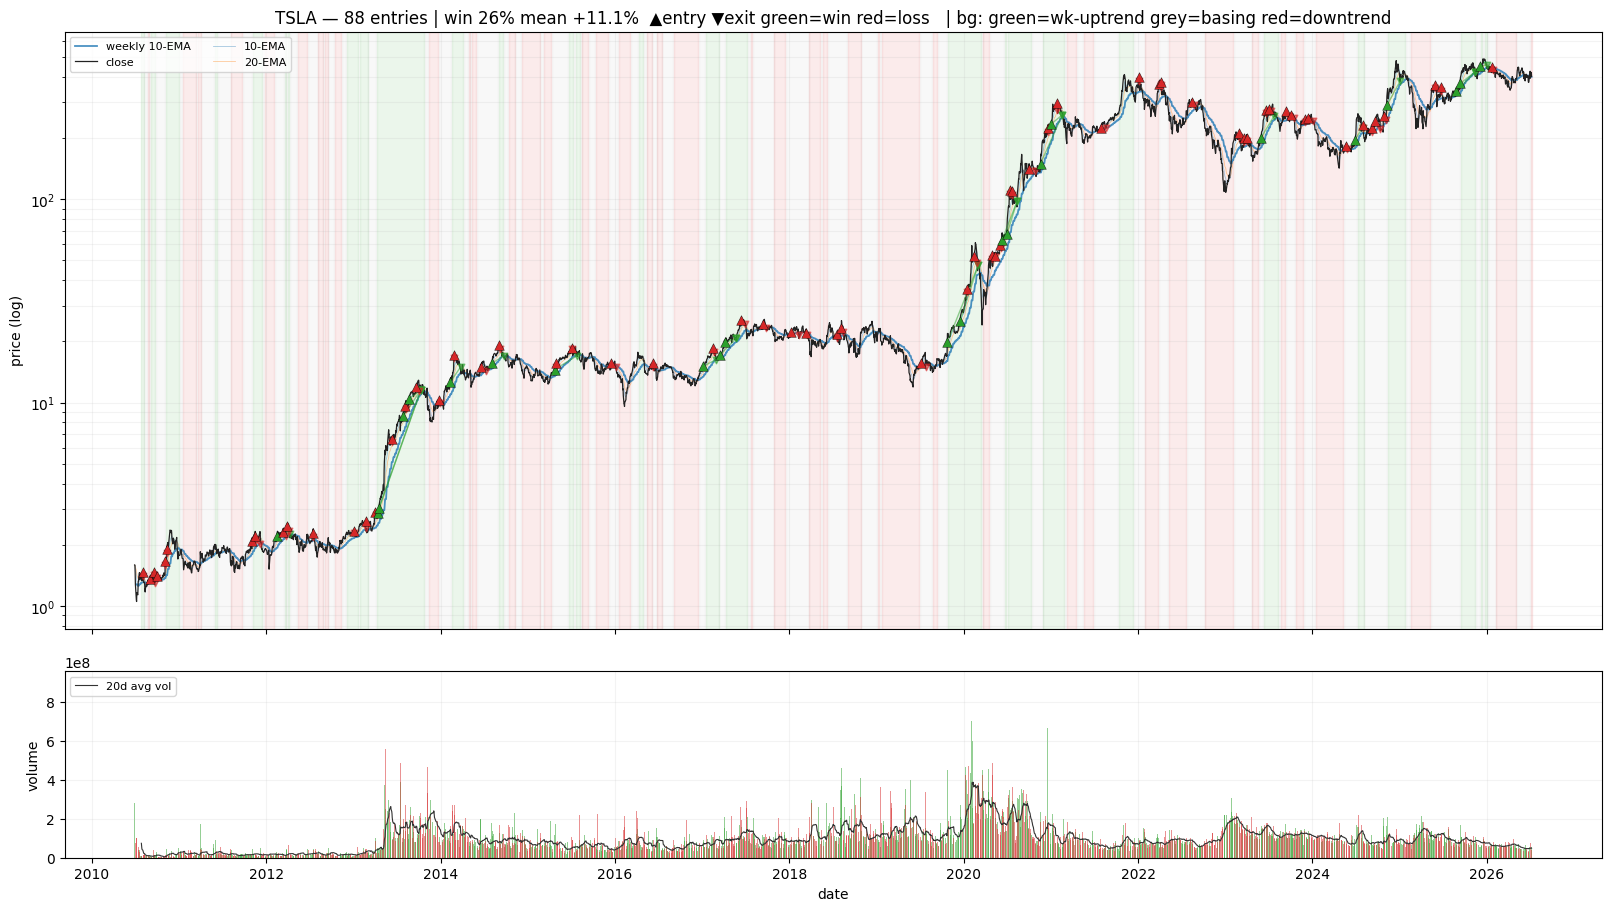

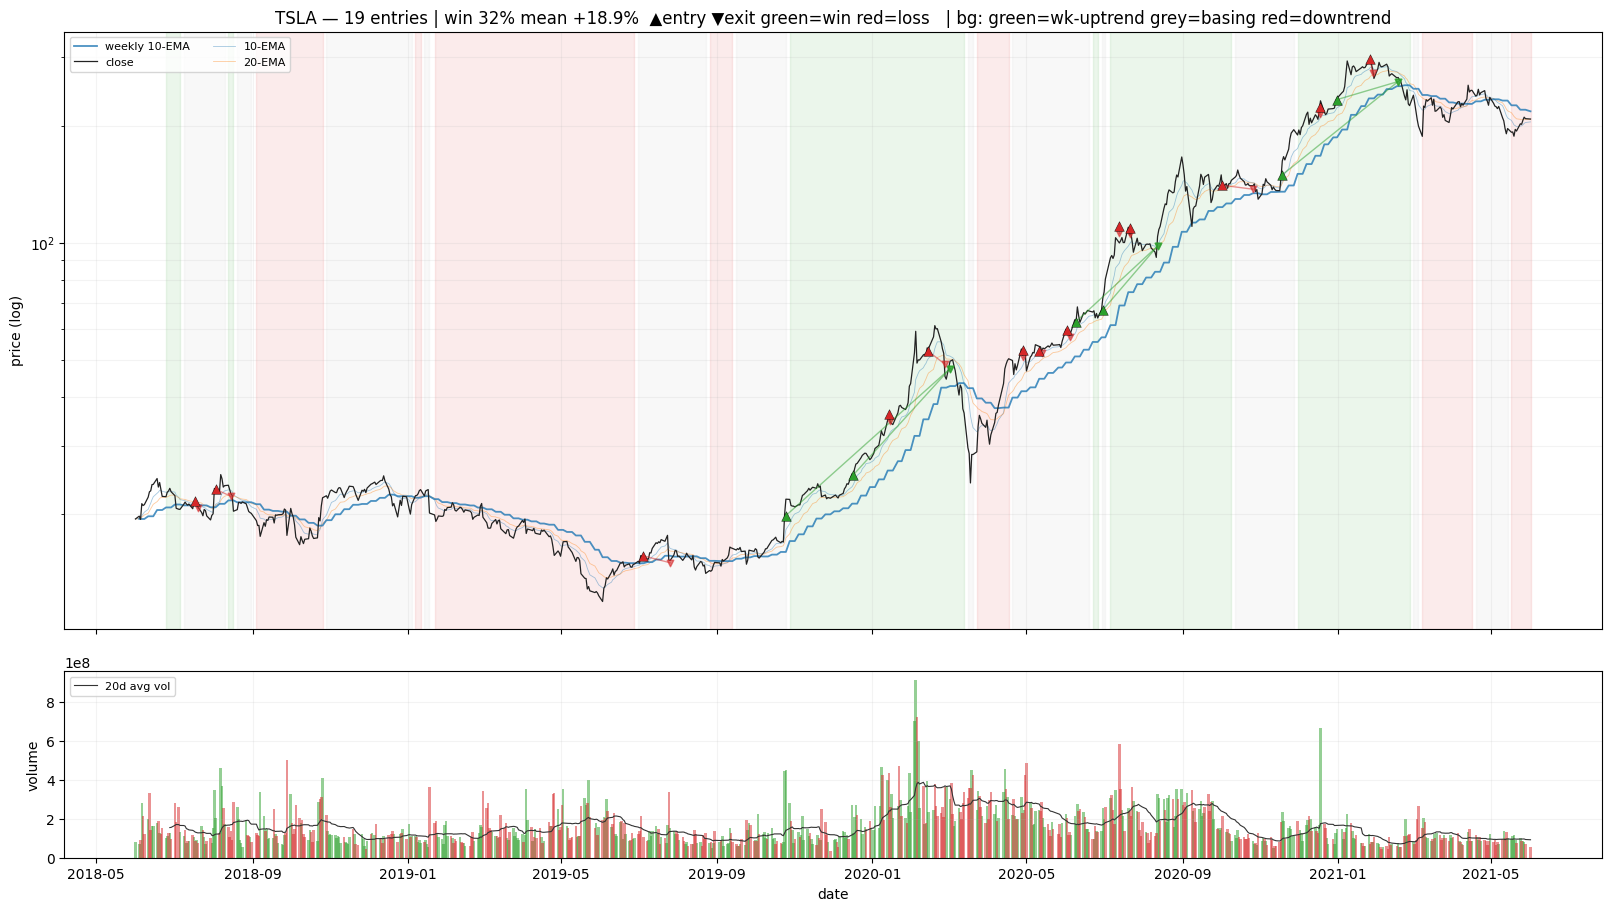

In [1]:
%matplotlib inline
import pandas as pd
from agents.evaluator.eval import viz

# load a trade file (any exit — swap the name to visualize a different exit)
d = pd.read_parquet('../evaluator/runs/setups_all_wk1035.parquet')

# the standard "investable + liquid" slice we've been using
inv = d[d.weekly_trend_state.isin(['basing','uptrend'])
      & d.trend_state.isin(['basing','uptrend'])].query('avg_dollar_vol_20d > 500000')

viz.plot_ticker('TSLA', inv)                                       # whole history
viz.plot_ticker('TSLA', inv, start='2018-06-01', end='2021-06-01') 